In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

TRANSACTION COLUMNS:


NameError: name 'transactions' is not defined

In [2]:
base_path = Path(r"C:\Users\hp\Downloads\drive-download-20260731T054819Z-1-001")

fund_master = pd.read_csv(base_path / "01_fund_master.csv")
nav = pd.read_csv(base_path / "02_nav_history.csv")
aum = pd.read_csv(base_path / "03_aum_by_fund_house.csv")
sip = pd.read_csv(base_path / "04_monthly_sip_inflows.csv")
category = pd.read_csv(base_path / "05_category_inflows.csv")
folio = pd.read_csv(base_path / "06_industry_folio_count.csv")
performance = pd.read_csv(base_path / "07_scheme_performance.csv")
transactions = pd.read_csv(base_path / "08_investor_transactions.csv")
holdings = pd.read_csv(base_path / "09_portfolio_holdings.csv")
benchmark = pd.read_csv(base_path / "10_benchmark_indices.csv")

print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [3]:
print("FUND MASTER")
print(fund_master.columns.tolist())

print("\nNAV")
print(nav.columns.tolist())

print("\nTRANSACTIONS")
print(transactions.columns.tolist())

print("\nHOLDINGS")
print(holdings.columns.tolist())

print("\nPERFORMANCE")
print(performance.columns.tolist())

print("\nBENCHMARK")
print(benchmark.columns.tolist())


FUND MASTER
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV
['amfi_code', 'date', 'nav']

TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

BENCHMARK
['date', 'index_name', 'close_value']


In [13]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).copy()

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav_returns = nav.dropna(
    subset=["daily_return"]
).copy()

print("Total return observations:", len(nav_returns))
print("Number of funds:", nav_returns["amfi_code"].nunique())

Total return observations: 45960
Number of funds: 40


In [14]:
 

nav = nav.sort_values(["amfi_code", "date"]).copy()

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

nav_returns = nav.dropna(
    subset=["daily_return"]
).copy()

print("Number of funds:", nav_returns["amfi_code"].nunique())
print("Number of return observations:", len(nav_returns))

nav_returns.head()

Number of funds: 40
Number of return observations: 45960


,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [5]:
var_results = []

for code, group in nav_returns.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar_df = pd.DataFrame(var_results)

var_cvar_df = var_cvar_df.sort_values(
    "VaR_95"
)

var_cvar_df.head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [19]:

var_results = []

for code, group in nav_returns.groupby("amfi_code"):

    returns = group["daily_return"].dropna()


    var95 = returns.quantile(0.05)

    
    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar_df = pd.DataFrame(var_results)


var_cvar_df = var_cvar_df.sort_values(
    "VaR_95"
)

print(var_cvar_df.head(10))

    amfi_code    VaR_95   CVaR_95
22     119599 -0.026859 -0.032384
17     119095 -0.026188 -0.031667
4      101207 -0.026021 -0.032459
11     118634 -0.025438 -0.032304
21     119598 -0.024507 -0.030595
39     149324 -0.023483 -0.031036
7      102886 -0.019220 -0.023251
2      100033 -0.019034 -0.023456
25     120505 -0.018892 -0.024342
16     119094 -0.018480 -0.024260


In [20]:
var_cvar_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully.")

var_cvar_report.csv created successfully.


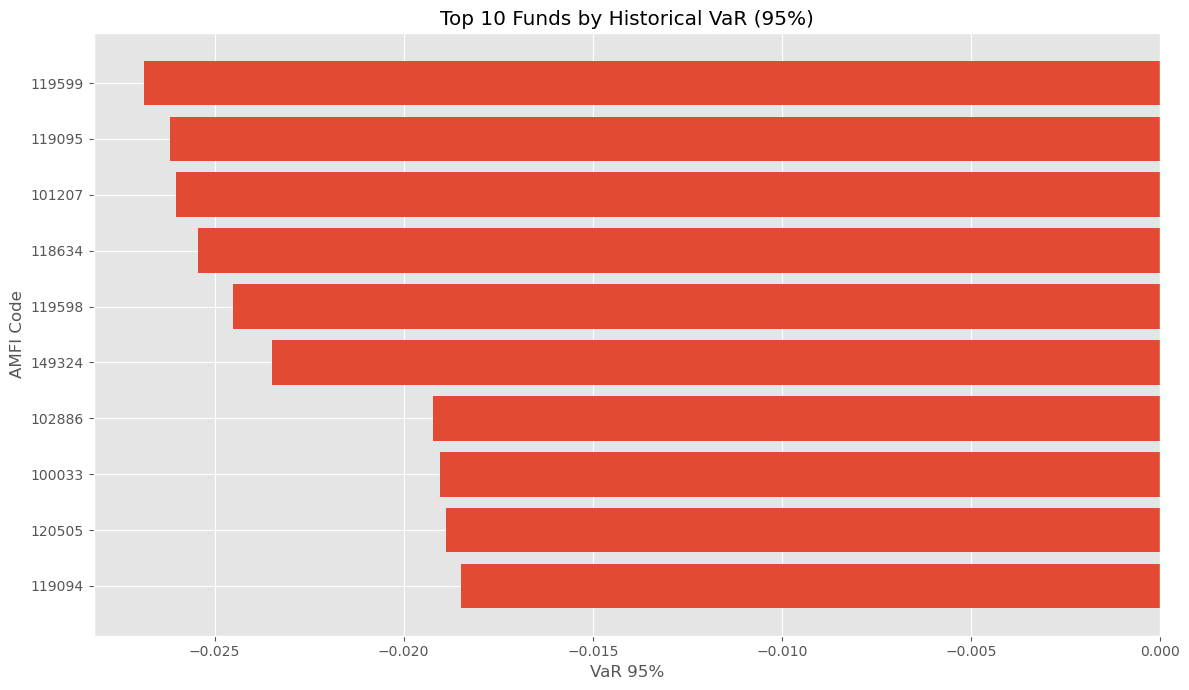

In [21]:
top10_var = var_cvar_df.head(10)

plt.figure(figsize=(12, 7))

plt.barh(
    top10_var["amfi_code"].astype(str),
    top10_var["VaR_95"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Funds by Historical VaR (95%)"
)

plt.xlabel("VaR 95%")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    "01_Historical_VaR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
rolling_sharpe = nav_returns.copy()

rolling_sharpe["rolling_mean"] = (
    rolling_sharpe
    .groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

rolling_sharpe["rolling_std"] = (
    rolling_sharpe
    .groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

rolling_sharpe["rolling_sharpe"] = (
    rolling_sharpe["rolling_mean"]
    / rolling_sharpe["rolling_std"]
    * np.sqrt(252)
)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN
5755,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN


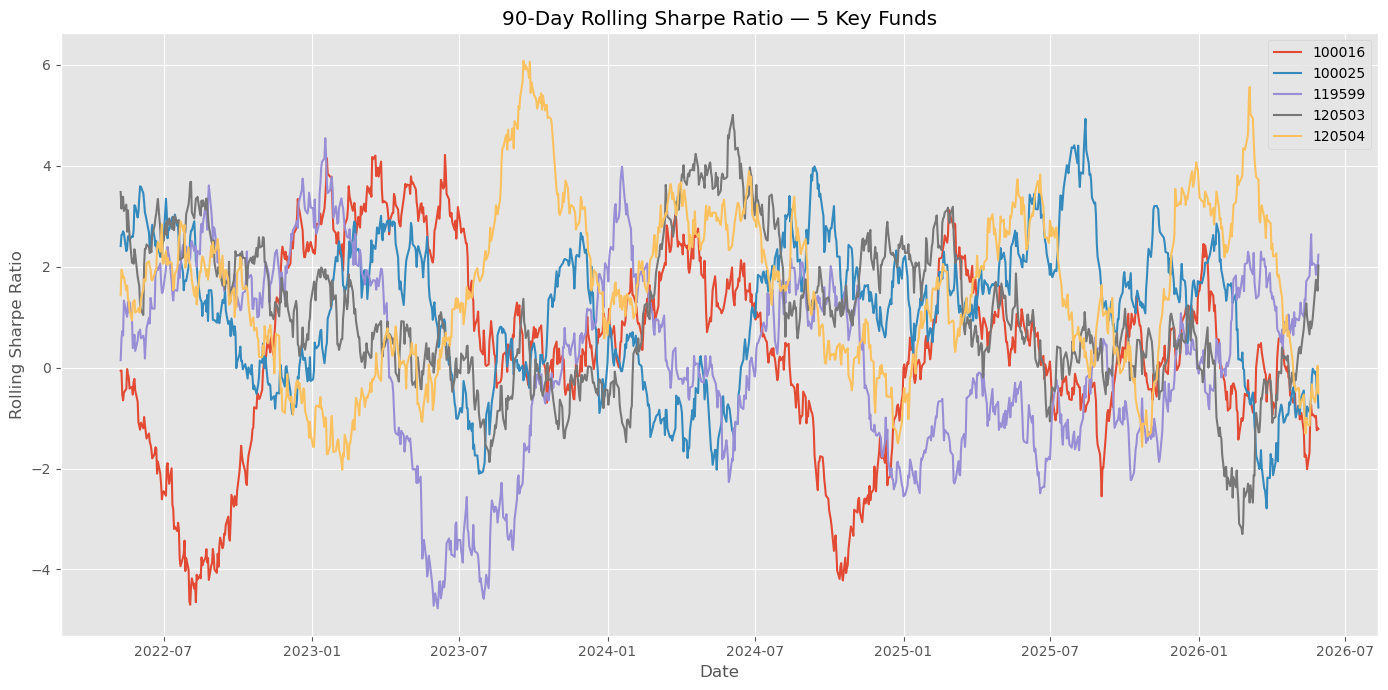

In [10]:
plt.figure(figsize=(14, 7))

for code in key_funds:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code),
        linewidth=1.5
    )

plt.title("90-Day Rolling Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Select 5 funds for rolling Sharpe analysis

key_funds = (
    nav_returns["amfi_code"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Selected funds:", key_funds)

Selected funds: [100016, 100025, 119599, 120503, 120504]


In [27]:


transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_year"] = (
    transactions["transaction_date"]
    .dt.year
)

print(transactions[
    ["investor_id", "transaction_date", "amount_inr", "amfi_code", "cohort_year"]
].head())

  investor_id transaction_date  amount_inr  amfi_code  cohort_year
0   INV003054       2024-01-01        1834     119092         2024
1   INV002952       2024-01-01      392882     148567         2024
2   INV003420       2024-01-01         912     118636         2024
3   INV003436       2024-01-01        1102     118634         2024
4   INV004691       2024-01-01        8682     119094         2024


In [28]:

cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique"),
        avg_transaction_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        transactions=("investor_id", "count")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,investors,avg_transaction_amount,total_invested,transactions
0,2024,4803,107739.476605,2500633252,23210
1,2025,4018,106704.345527,1020947178,9568


In [29]:
 

cohort_fund = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    cohort_fund
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
    .rename(columns={"amfi_code": "top_fund"})
)

cohort_analysis = cohort_analysis.merge(
    top_funds[
        ["cohort_year", "top_fund", "transaction_count"]
    ],
    on="cohort_year",
    how="left"
)

cohort_analysis

,cohort_year,investors,avg_transaction_amount,total_invested,transactions,top_fund,transaction_count
0,2024,4803,107739.476605,2500633252,23210,119094,625
1,2025,4018,106704.345527,1020947178,9568,119551,271


In [30]:
cohort_analysis.to_csv(
    "investor_cohort_analysis.csv",
    index=False
)

print("Investor cohort analysis saved successfully.")

Investor cohort analysis saved successfully.


In [31]:
 

sip_transactions = transactions[
    transactions["transaction_type"].astype(str).str.upper() == "SIP"
].copy()

sip_transactions["transaction_date"] = pd.to_datetime(
    sip_transactions["transaction_date"]
)

sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

print("Total SIP transactions:", len(sip_transactions))
print("Unique SIP investors:", sip_transactions["investor_id"].nunique())

Total SIP transactions: 19716
Unique SIP investors: 4762


In [32]:
 

sip_transactions["gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,first_transaction_date,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024-11-04,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024-11-04,2025,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024-03-29,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024-03-29,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024-03-29,2025,238.0


In [33]:
 
sip_counts = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

Investors with 6+ SIP transactions: 1362


In [34]:
# Calculate average gap for eligible investors

sip_continuity = (
    sip_transactions[
        sip_transactions["investor_id"].isin(
            eligible_investors["investor_id"]
        )
    ]
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max")
    )
    .reset_index()
)

sip_continuity

,investor_id,sip_count,avg_gap_days,max_gap_days
0,INV000004,6,85.400000,265.0
1,INV000008,6,70.400000,165.0
2,INV000010,6,64.800000,139.0
3,INV000011,7,40.166667,125.0
4,INV000012,8,57.000000,132.0
...,...,...,...,...
1357,INV004984,7,75.333333,177.0
1358,INV004986,7,81.333333,185.0
1359,INV004992,7,81.500000,176.0
1360,INV004996,10,46.333333,104.0


In [37]:
# Investors with average SIP gap greater than 35 days
# are classified as at-risk

sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

sip_continuity

,investor_id,sip_count,avg_gap_days,max_gap_days,status
0,INV000004,6,85.400000,265.0,At-Risk
1,INV000008,6,70.400000,165.0,At-Risk
2,INV000010,6,64.800000,139.0,At-Risk
3,INV000011,7,40.166667,125.0,At-Risk
4,INV000012,8,57.000000,132.0,At-Risk
...,...,...,...,...,...
1357,INV004984,7,75.333333,177.0,At-Risk
1358,INV004986,7,81.333333,185.0,At-Risk
1359,INV004992,7,81.500000,176.0,At-Risk
1360,INV004996,10,46.333333,104.0,At-Risk


In [38]:
sip_continuity.to_csv(
    "sip_continuity_analysis.csv",
    index=False
)

print("SIP continuity analysis saved successfully.")

print(
    "\nAt-Risk Investors:",
    (sip_continuity["status"] == "At-Risk").sum()
)

print(
    "Regular Investors:",
    (sip_continuity["status"] == "Regular").sum()
)

SIP continuity analysis saved successfully.

At-Risk Investors: 1332
Regular Investors: 30


In [39]:
# Simple Fund Recommender

# Merge Sharpe ratio with fund master information
recommender_df = performance[
    ["amfi_code", "scheme_name", "risk_grade", "sharpe_ratio"]
].copy()

# Remove missing values
recommender_df = recommender_df.dropna(
    subset=["risk_grade", "sharpe_ratio"]
)

# Function to recommend top 3 funds
def recommend_funds(risk_appetite):
    
    matching = recommender_df[
        recommender_df["risk_grade"].str.lower()
        == risk_appetite.lower()
    ].copy()

    result = (
        matching
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
    )

    return result[
        ["amfi_code", "scheme_name", "risk_grade", "sharpe_ratio"]
    ]

In [41]:
print("LOW RISK FUNDS")
print(recommend_funds("Low"))

print("\nMODERATE RISK FUNDS")
print(recommend_funds("Moderate"))

print("\nHIGH RISK FUNDS")
print(recommend_funds("High"))

LOW RISK FUNDS
    amfi_code                               scheme_name risk_grade  \
14     120507  ICICI Pru Liquid Fund - Regular - Growth        Low   
23     120844      Kotak Liquid Fund - Regular - Growth        Low   
30     101208       ABSL Liquid Fund - Regular - Growth        Low   

    sharpe_ratio  
14          7.68  
23          6.18  
30          5.14  

MODERATE RISK FUNDS
    amfi_code                                    scheme_name risk_grade  \
5      100016      HDFC Top 100 Fund - Regular Plan - Growth   Moderate   
34     148567  Mirae Asset Large Cap Fund - Regular - Growth   Moderate   
11     120504      ICICI Pru Bluechip Fund - Direct - Growth   Moderate   

    sharpe_ratio  
5           1.06  
34          1.06  
11          1.03  

HIGH RISK FUNDS
    amfi_code                                    scheme_name risk_grade  \
21     120842  Kotak Emerging Equity Fund - Regular - Growth       High   
12     120505       ICICI Pru Midcap Fund - Regular - Growth   

In [42]:
 
recommender_code = '''
import pandas as pd

def recommend_funds(risk_appetite):
    """
    Recommend top 3 mutual funds based on Sharpe ratio
    for the selected risk appetite.
    
    Risk appetite:
    Low / Moderate / High
    """

    performance = pd.read_csv("07_scheme_performance.csv")

    df = performance[
        ["amfi_code", "scheme_name", "risk_grade", "sharpe_ratio"]
    ].dropna()

    matching = df[
        df["risk_grade"].str.lower() == risk_appetite.lower()
    ]

    return (
        matching
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
    )


if __name__ == "__main__":
    risk = input("Enter risk appetite (Low / Moderate / High): ")

    result = recommend_funds(risk)

    print("\\nTop 3 Recommended Funds:")
    print(result.to_string(index=False))
'''

with open("recommender.py", "w", encoding="utf-8") as f:
    f.write(recommender_code)

print("recommender.py created successfully.")

recommender.py created successfully.


In [43]:
 

holdings["weight_decimal"] = holdings["weight_pct"] / 100

sector_hhi = (
    holdings
    .groupby(["amfi_code", "sector"])["weight_decimal"]
    .sum()
    .reset_index()
)

hhi_df = (
    sector_hhi
    .groupby("amfi_code")["weight_decimal"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi_df = hhi_df.sort_values(
    "HHI",
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI
11,119092,0.296769
30,148569,0.254992
27,125498,0.253155
6,102887,0.251383
32,149323,0.241077
21,120505,0.238695
10,118635,0.237497
18,119599,0.232361
22,120506,0.231464
1,100033,0.227647


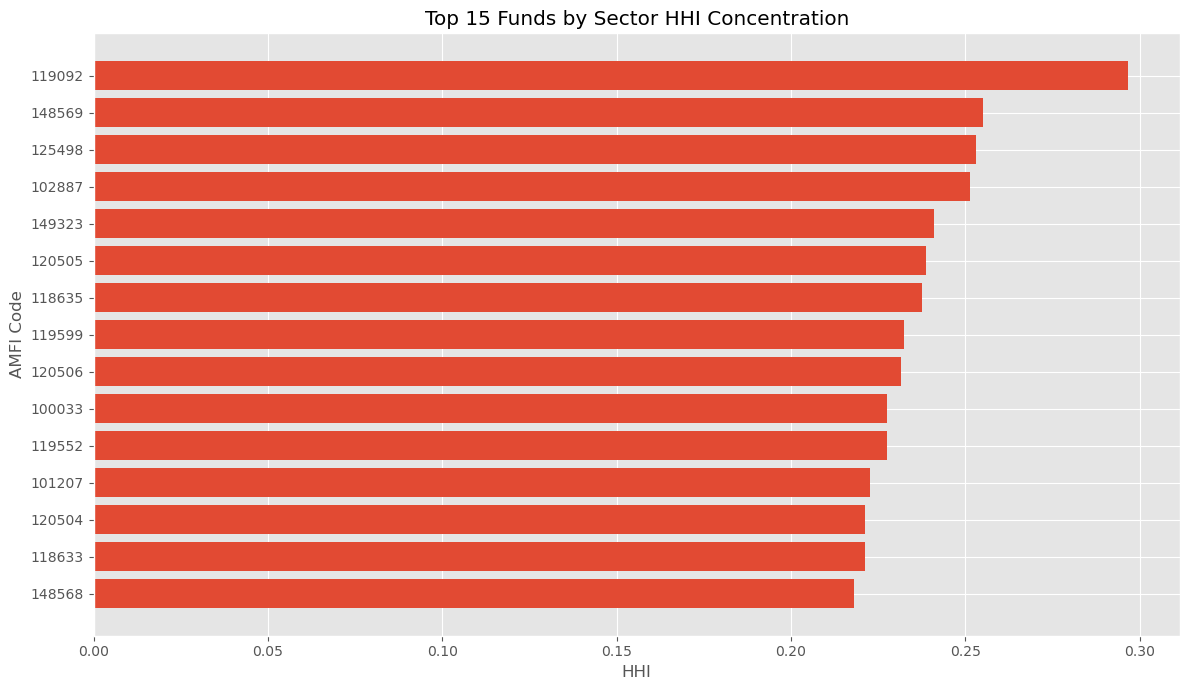

In [44]:
plt.figure(figsize=(12, 7))

top_hhi = hhi_df.head(15)

plt.barh(
    top_hhi["amfi_code"].astype(str),
    top_hhi["HHI"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Funds by Sector HHI Concentration")
plt.xlabel("HHI")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    "sector_hhi_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
hhi_df.to_csv(
    "sector_hhi.csv",
    index=False
)

print("Sector HHI analysis saved successfully.")

Sector HHI analysis saved successfully.


In [47]:
# Key numbers for advanced insights

print("===== ADVANCED INSIGHTS DATA =====")

# 1. Historical VaR and CVaR
print("\nHighest Risk Funds by VaR:")
print(
    var_cvar_df
    .sort_values("VaR_95")
    .head(5)[["amfi_code", "VaR_95", "CVaR_95"]]
)

# 2. Investor cohorts
print("\nInvestor Cohorts:")
print(
    cohort_analysis[
        ["cohort_year", "investors",
         "avg_transaction_amount", "total_invested"]
    ]
    .sort_values("total_invested", ascending=False)
)

# 3. SIP continuity
total_eligible = len(sip_continuity)

at_risk = (
    sip_continuity["status"] == "At-Risk"
).sum()

regular = (
    sip_continuity["status"] == "Regular"
).sum()

print("\nSIP Continuity:")
print("Eligible investors:", total_eligible)
print("At-risk investors:", at_risk)
print("Regular investors:", regular)

if total_eligible > 0:
    print(
        "Regular continuity rate:",
        round(regular / total_eligible * 100, 2),
        "%"
    )

# 4. Sector HHI
print("\nHighest Sector Concentration:")
print(hhi_df.head(5))

print("\nLowest Sector Concentration:")
print(hhi_df.tail(5))

===== ADVANCED INSIGHTS DATA =====

Highest Risk Funds by VaR:
    amfi_code    VaR_95   CVaR_95
22     119599 -0.026859 -0.032384
17     119095 -0.026188 -0.031667
4      101207 -0.026021 -0.032459
11     118634 -0.025438 -0.032304
21     119598 -0.024507 -0.030595

Investor Cohorts:
   cohort_year  investors  avg_transaction_amount  total_invested
0         2024       4803           107739.476605      2500633252
1         2025       4018           106704.345527      1020947178

SIP Continuity:
Eligible investors: 1362
At-risk investors: 1332
Regular investors: 30
Regular continuity rate: 2.2 %

Highest Sector Concentration:
    amfi_code       HHI
11     119092  0.296769
30     148569  0.254992
27     125498  0.253155
6      102887  0.251383
32     149323  0.241077

Lowest Sector Concentration:
    amfi_code       HHI
9      118634  0.160299
14     119095  0.159582
15     119551  0.142491
25     120843  0.136206
5      102886  0.124020


# Advanced Insights

print("""
ADVANCED ANALYTICS INSIGHTS

1. Historical VaR/CVaR:
The highest downside risk was observed among the funds with the most negative
5th-percentile daily returns. AMFI 119599 recorded the lowest VaR at approximately
-2.69%, indicating comparatively higher historical downside risk.

2. Investor Cohorts:
The 2024 investor cohort was larger and invested substantially more than the
2025 cohort, with approximately 4,803 investors and ₹250.06 crore in total
investment compared with 4,018 investors and ₹102.09 crore for 2025.

3. SIP Continuity:
Among 1,362 investors with at least six SIP transactions, 1,332 were classified
as at-risk because their average SIP gap exceeded 35 days. Only 30 investors
were classified as regular, giving a continuity rate of approximately 2.2%.

4. Sector Concentration:
AMFI 119092 had the highest sector HHI of approximately 0.297, indicating a
relatively concentrated sector allocation. AMFI 102886 had the lowest HHI of
approximately 0.124, indicating comparatively better sector diversification.

5. Risk Monitoring:
The VaR, rolling Sharpe, SIP continuity and HHI analyses together provide a
broader view of fund and investor risk. Historical downside risk should be
considered alongside risk-adjusted returns, investor behaviour and portfolio
concentration when evaluating funds.
""")

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import os

# Project folder
PROJECT = Path(r"C:\Users\hp\OneDrive\Documents\MutualFundAnalytics")

# Find the raw-data folder automatically
raw = PROJECT / "data" / "raw"

# If data/raw doesn't exist, search the project for the files
if not raw.exists():
    raw = PROJECT

def load_file(filename):
    matches = list(PROJECT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename}")
    return pd.read_csv(matches[0])

# Load D6 datasets
fund_master = load_file("01_fund_master.csv")
nav = load_file("02_nav_history.csv")
performance = load_file("07_scheme_performance.csv")
transactions = load_file("08_investor_transactions.csv")

print("DATA LOADED SUCCESSFULLY")
print("-" * 50)

print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)

print("\nTRANSACTION COLUMNS:")
print(transactions.columns.tolist())

print("\nFUND MASTER COLUMNS:")
print(fund_master.columns.tolist())

print("\nPERFORMANCE COLUMNS:")
print(performance.columns.tolist())

DATA LOADED SUCCESSFULLY
--------------------------------------------------
Fund Master: (40, 15)
NAV: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)

TRANSACTION COLUMNS:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

FUND MASTER COLUMNS:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

PERFORMANCE COLUMNS:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [6]:
# ==========================================
# D6 - COHORT ANALYSIS
# ==========================================

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("data/processed", exist_ok=True)

txn = transactions.copy()

# Clean numeric field
txn["amount_inr"] = pd.to_numeric(txn["amount_inr"], errors="coerce")

# Remove rows missing important cohort information
txn = txn.dropna(
    subset=["amount_inr", "age_group", "state", "city_tier"]
)

# ------------------------------------------
# AGE GROUP
# ------------------------------------------

age_analysis = (
    txn.groupby("age_group")
    .agg({
        "amount_inr": ["sum", "mean"]
    })
    .reset_index()
)

age_analysis.columns = [
    "age_group",
    "total_amount",
    "average_amount"
]

age_analysis["transactions"] = (
    txn.groupby("age_group")
       .size()
       .values
)

age_analysis = age_analysis.sort_values(
    "total_amount",
    ascending=False
)

print("AGE GROUP ANALYSIS")
print(age_analysis)

age_analysis.to_csv(
    "data/processed/age_group_analysis.csv",
    index=False
)


# ------------------------------------------
# STATE
# ------------------------------------------

state_analysis = (
    txn.groupby("state")
    .agg({
        "amount_inr": ["sum", "mean"]
    })
    .reset_index()
)

state_analysis.columns = [
    "state",
    "total_amount",
    "average_amount"
]

state_analysis["transactions"] = (
    txn.groupby("state")
       .size()
       .values
)

state_analysis = state_analysis.sort_values(
    "total_amount",
    ascending=False
)

print("\nTOP 10 STATES")
print(state_analysis.head(10))

state_analysis.to_csv(
    "data/processed/state_analysis.csv",
    index=False
)


# ------------------------------------------
# CITY TIER
# ------------------------------------------

city_tier_analysis = (
    txn.groupby("city_tier")
    .agg({
        "amount_inr": ["sum", "mean"]
    })
    .reset_index()
)

city_tier_analysis.columns = [
    "city_tier",
    "total_amount",
    "average_amount"
]

city_tier_analysis["transactions"] = (
    txn.groupby("city_tier")
       .size()
       .values
)

city_tier_analysis = city_tier_analysis.sort_values(
    "total_amount",
    ascending=False
)

print("\nCITY TIER ANALYSIS")
print(city_tier_analysis)

city_tier_analysis.to_csv(
    "data/processed/city_tier_analysis.csv",
    index=False
)


# ------------------------------------------
# TRANSACTION TYPE
# ------------------------------------------

transaction_type_analysis = (
    txn.groupby("transaction_type")
    .agg({
        "amount_inr": ["sum", "mean"]
    })
    .reset_index()
)

transaction_type_analysis.columns = [
    "transaction_type",
    "total_amount",
    "average_amount"
]

transaction_type_analysis["transactions"] = (
    txn.groupby("transaction_type")
       .size()
       .values
)

transaction_type_analysis = transaction_type_analysis.sort_values(
    "total_amount",
    ascending=False
)

print("\nTRANSACTION TYPE ANALYSIS")
print(transaction_type_analysis)

transaction_type_analysis.to_csv(
    "data/processed/transaction_type_analysis.csv",
    index=False
)


print("\nD6 COHORT ANALYSIS COMPLETED SUCCESSFULLY.")

AGE GROUP ANALYSIS
  age_group  total_amount  average_amount  transactions
1     26-35    1451600218   107821.452722         13463
2     36-45     871647528   107003.133808          8146
0     18-25     531639392   108144.709520          4916
3     46-55     405406469   107278.769251          3779
4       56+     261286823   105613.105497          2474

TOP 10 STATES
             state  total_amount  average_amount  transactions
6           Punjab     315780459   106502.684317          2965
8       Tamil Nadu     315177237   112322.607627          2806
4   Madhya Pradesh     308312493   105190.205732          2931
7        Rajasthan     298645822   115888.949166          2577
1          Gujarat     298358940   107323.359712          2780
11     West Bengal     297182514   108145.019651          2748
9        Telangana     290219284   106776.778514          2718
0            Delhi     289633404   108193.277549          2677
10   Uttar Pradesh     285368873   105888.264564          2695


In [7]:
# ==========================================
# D6 - FUND RECOMMENDER
# ==========================================

import pandas as pd
import numpy as np
import os

# Use scheme performance + fund master
perf = performance.copy()
funds = fund_master.copy()

# Keep useful columns
recommendation = perf[
    [
        "amfi_code",
        "scheme_name",
        "category",
        "return_1yr_pct",
        "std_dev_ann_pct",
        "sharpe_ratio",
        "sortino_ratio",
        "max_drawdown_pct",
        "risk_grade"
    ]
].copy()

# Convert numeric columns
numeric_cols = [
    "return_1yr_pct",
    "std_dev_ann_pct",
    "sharpe_ratio",
    "sortino_ratio",
    "max_drawdown_pct"
]

for col in numeric_cols:
    recommendation[col] = pd.to_numeric(
        recommendation[col],
        errors="coerce"
    )

# Remove incomplete records
recommendation = recommendation.dropna(
    subset=[
        "return_1yr_pct",
        "std_dev_ann_pct",
        "sharpe_ratio"
    ]
)

# ------------------------------------------
# Recommendation Score
# ------------------------------------------

# Higher return = better
return_score = (
    recommendation["return_1yr_pct"]
    .rank(pct=True) * 40
)

# Higher Sharpe = better
sharpe_score = (
    recommendation["sharpe_ratio"]
    .rank(pct=True) * 30
)

# Lower volatility = better
risk_score = (
    (1 - recommendation["std_dev_ann_pct"].rank(pct=True)) * 20
)

# Higher Sortino = better
sortino_score = (
    recommendation["sortino_ratio"].rank(pct=True) * 10
)

recommendation["recommendation_score"] = (
    return_score
    + sharpe_score
    + risk_score
    + sortino_score
)

# Rank funds
recommendation = recommendation.sort_values(
    "recommendation_score",
    ascending=False
).reset_index(drop=True)

recommendation["recommendation_rank"] = (
    recommendation.index + 1
)

# Recommendation label
recommendation["recommendation"] = np.where(
    recommendation["recommendation_rank"] <= 5,
    "Top Pick",
    np.where(
        recommendation["recommendation_rank"] <= 15,
        "Strong Candidate",
        "Watchlist"
    )
)

print("TOP 10 RECOMMENDED FUNDS")
print(
    recommendation[
        [
            "recommendation_rank",
            "amfi_code",
            "scheme_name",
            "category",
            "return_1yr_pct",
            "sharpe_ratio",
            "std_dev_ann_pct",
            "recommendation_score",
            "recommendation"
        ]
    ].head(10)
)

# Save D6 output
os.makedirs("data/processed", exist_ok=True)

recommendation.to_csv(
    "data/processed/fund_recommendations.csv",
    index=False
)

print("\nFUND RECOMMENDER COMPLETED SUCCESSFULLY.")
print("Saved: data/processed/fund_recommendations.csv")

TOP 10 RECOMMENDED FUNDS
   recommendation_rank  amfi_code  \
0                    1     118632   
1                    2     148567   
2                    3     120506   
3                    4     120507   
4                    5     120843   
5                    6     102887   
6                    7     119598   
7                    8     119599   
8                    9     101208   
9                   10     100025   

                                         scheme_name        category  \
0     Nippon India Large Cap Fund - Regular - Growth       Large Cap   
1      Mirae Asset Large Cap Fund - Regular - Growth       Large Cap   
2  ICICI Pru Value Discovery Fund - Regular - Growth           Value   
3           ICICI Pru Liquid Fund - Regular - Growth          Liquid   
4             Kotak Flexicap Fund - Regular - Growth       Flexi Cap   
5              UTI Flexi Cap Fund - Regular - Growth       Flexi Cap   
6         SBI Small Cap Fund - Regular Plan - Growth       Smal

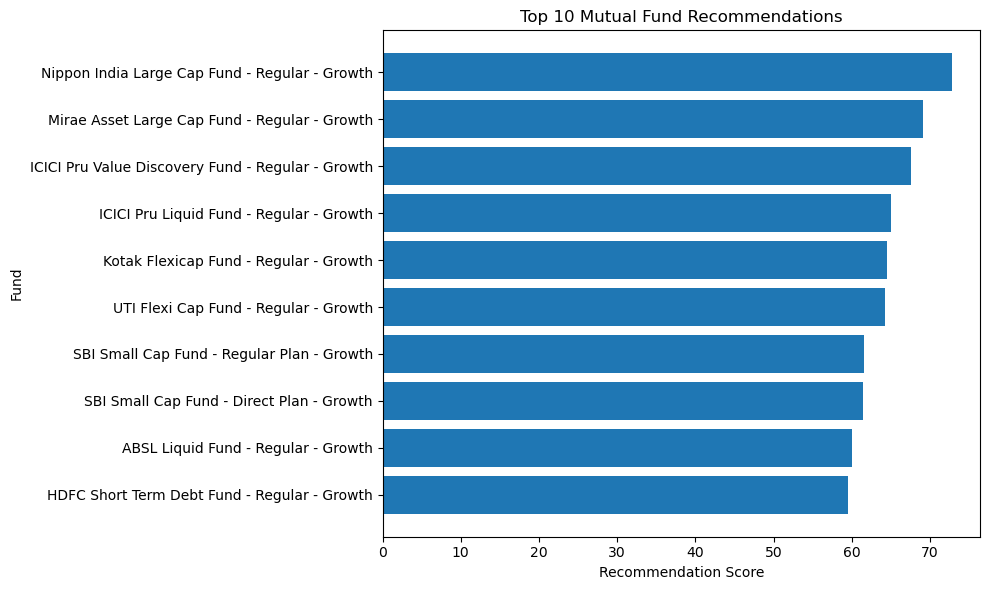

D6 recommendation visualization saved successfully.


In [8]:
# ==========================================
# D6 - RECOMMENDATION VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

top10 = recommendation.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top10["scheme_name"].astype(str),
    top10["recommendation_score"]
)

plt.xlabel("Recommendation Score")
plt.ylabel("Fund")
plt.title("Top 10 Mutual Fund Recommendations")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "data/processed/top10_fund_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("D6 recommendation visualization saved successfully.")

In [9]:
import os

print("D6 OUTPUT FILES")
print("=" * 40)

for file in sorted(os.listdir("data/processed")):
    print(file)

D6 OUTPUT FILES
age_group_analysis.csv
city_tier_analysis.csv
fund_recommendations.csv
state_analysis.csv
top10_fund_recommendations.png
transaction_type_analysis.csv
